# 1. Первичный анализ и обработка датафрейма

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
sber = pd.read_csv(r'C:\Users\user\Desktop\AlgoTrading\data\SBRF.txt')

In [3]:
sber

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,SBRF,1,20090111,103000,2301,2335,2301,2321,123
1,SBRF,1,20090111,103100,2321,2321,2265,2269,194
2,SBRF,1,20090111,103200,2310,2344,2310,2344,383
3,SBRF,1,20090111,103300,2344,2346,2333,2333,67
4,SBRF,1,20090111,103400,2334,2334,2334,2334,2
...,...,...,...,...,...,...,...,...,...
3298843,SBRF,1,20250630,234400,29851,29851,29845,29845,28
3298844,SBRF,1,20250630,234500,29843,29845,29829,29845,39
3298845,SBRF,1,20250630,234700,29828,29828,29827,29827,3
3298846,SBRF,1,20250630,234800,29832,29841,29805,29815,262


In [4]:
def good_dataframe(data, timeframe):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    
    """
  # 1. Делаем копию, чтобы не изменялся исходный датафрейм
  data = data.copy()
  
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['ticker', 'per', 'date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
  
  # 7. Установка индекса
  data_final = data.set_index('time')
  
  
  
  def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """

    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'ticker': 'first',
            'per': 'first',
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    

    return_data['per'] = timeframe
    return return_data
  
  result = new_timeframe(data_final, timeframe)
  
  result = result.reset_index()
  
  return result


In [5]:
sber_1h = good_dataframe(sber, '4h')
sber_1h

,time,ticker,per,open,high,low,close,volume
0,2009-01-11 08:00:00,SBRF,4h,2301.0,2380.0,2265.0,2346.0,13466
1,2009-01-11 12:00:00,SBRF,4h,2346.0,2354.0,2319.0,2320.0,5528
2,2009-01-11 16:00:00,SBRF,4h,2321.0,2358.0,2319.0,2343.0,6260
3,2009-01-11 20:00:00,SBRF,4h,2343.0,2359.0,2335.0,2353.0,1250
4,2009-01-12 08:00:00,SBRF,4h,2345.0,2353.0,2323.0,2333.0,10626
...,...,...,...,...,...,...,...,...
16656,2025-06-27 20:00:00,SBRF,4h,29733.0,29745.0,29651.0,29686.0,6944
16657,2025-06-30 08:00:00,SBRF,4h,29750.0,29975.0,29679.0,29686.0,71639
16658,2025-06-30 12:00:00,SBRF,4h,29687.0,29870.0,29646.0,29838.0,40482
16659,2025-06-30 16:00:00,SBRF,4h,29839.0,29900.0,29793.0,29859.0,20053


In [6]:
l = []
for i in ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']:
    sber_tm = good_dataframe(sber, i)
    l.append(sber_tm)

# 2. Детекторы свечных паттернов
- Бычье поглощение / Медвежье поглощение - надо проверить
- Харами - надо проверить
- 3 свечи - надо проверить

Далее
- 3 звезды
- Пинцет
- Захват за пояс
- Просвет в облаках

- Повешенный или молот (надо оптимизировать размер тени)

## 1. Бычье поглощение / Медвежье поглощение
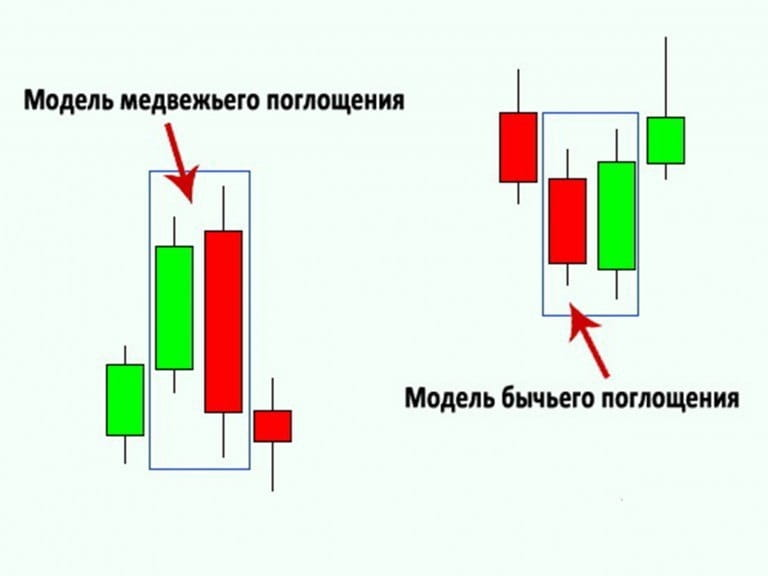

In [7]:
def detection_bullish_engulfing_pattern(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 'поглощение' (Bullish Engulfing) на ценовых данных.
    Функция позволяет применять дополнительные фильтры для подтверждения надежности паттерна.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_grow_candle_after_pattern' - паттерн подтверждается 1 растущей свечой после него
        - '2_grow_candle_after_pattern' - паттерн подтверждается 2 растущими свечами после него
        
        - '1_loss_candle_before_pattern' - паттерн подтверждается 1 падающей свечой до него  
        - '2_loss_candle_before_pattern' - паттерн подтверждается 2 падающими свечами до него
        
        

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий 
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_engulfing_pattern'
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body < 0) & 
        (body.shift(-1) > 0) &
        (data['open'] < data['close'].shift(-1)) & 
        (data['close'] > data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) > 0) & (body.shift(-3) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0) & (body.shift(2) < 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    
    data['filtr'] = filtr
    
    return data
        

In [8]:
def detection_bearish_engulfing_pattern(data, filtr='NO'):
    """
    Функция для детекции медвежьего паттерна 'поглощение' (Bearish Engulfing) на ценовых данных.
    Функция позволяет применять дополнительные фильтры для подтверждения надежности паттерна.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения медвежьим движением:
        - '1_loss_candle_after_pattern' - паттерн подтверждается 1 падающей свечой после него
        - '2_loss_candle_after_pattern' - паттерн подтверждается 2 падающими свечами после него
        
        - '1_grow_candle_before_pattern' - паттерн подтверждается 1 растущей свечой до него  
        - '2_grow_candle_before_pattern' - паттерн подтверждается 2 растущими свечами до него
        
    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленными колонками:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий
        
    """
    
    
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bearish_engulfing_pattern'
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие бычьего поглощения
    base_condition = (
        (body > 0) & 
        (body.shift(-1) < 0) &
        (data['open'] > data['close'].shift(-1)) & 
        (data['close'] < data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) < 0) & (body.shift(-3) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0) & (body.shift(2) > 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        

    data['filtr'] = filtr
    
    return data

In [9]:
sber_1h_bull = detection_bullish_engulfing_pattern(sber_1h)
sber_1h_bull

,time,ticker,per,open,high,low,close,volume,pattern,signal,strategy,filtr
0,2009-01-11 08:00:00,SBRF,4h,2301.0,2380.0,2265.0,2346.0,13466,0,0,bullish_engulfing_pattern,NO
1,2009-01-11 12:00:00,SBRF,4h,2346.0,2354.0,2319.0,2320.0,5528,0,0,bullish_engulfing_pattern,NO
2,2009-01-11 16:00:00,SBRF,4h,2321.0,2358.0,2319.0,2343.0,6260,0,0,bullish_engulfing_pattern,NO
3,2009-01-11 20:00:00,SBRF,4h,2343.0,2359.0,2335.0,2353.0,1250,0,0,bullish_engulfing_pattern,NO
4,2009-01-12 08:00:00,SBRF,4h,2345.0,2353.0,2323.0,2333.0,10626,0,0,bullish_engulfing_pattern,NO
...,...,...,...,...,...,...,...,...,...,...,...,...
16656,2025-06-27 20:00:00,SBRF,4h,29733.0,29745.0,29651.0,29686.0,6944,0,1,bullish_engulfing_pattern,NO
16657,2025-06-30 08:00:00,SBRF,4h,29750.0,29975.0,29679.0,29686.0,71639,0,0,bullish_engulfing_pattern,NO
16658,2025-06-30 12:00:00,SBRF,4h,29687.0,29870.0,29646.0,29838.0,40482,0,0,bullish_engulfing_pattern,NO
16659,2025-06-30 16:00:00,SBRF,4h,29839.0,29900.0,29793.0,29859.0,20053,0,0,bullish_engulfing_pattern,NO


## 2. Харами
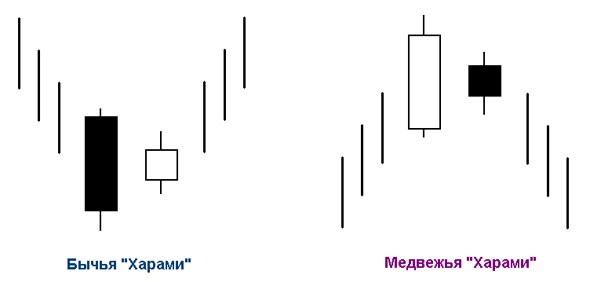

In [10]:
def detection_bullish_harami_pattern(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 'харами' (Bullish Harami) на ценовых данныx.
    Паттерн Харами состоит из большой медвежьей свечи, за которой следует маленькая бычья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_grow_candle_after_pattern' - паттерн подтверждается 1 растущей свечой после него
        - '2_grow_candle_after_pattern' - паттерн подтверждается 2 растущими свечами после него
        
        - '1_loss_candle_before_pattern' - паттерн подтверждается 1 падающей свечой до него  
        - '2_loss_candle_before_pattern' - паттерн подтверждается 2 падающими свечами до него
        
    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий 
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bullish_harami_pattern'
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие для бычьего харами
    base_condition = (
        (body < 0) & 
        (body.shift(-1) > 0) &
        (data['open'] > data['close'].shift(-1)) & 
        (data['close'] < data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) > 0) & (body.shift(-3) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) < 0) & (body.shift(2) < 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    data['filtr'] = filtr
    
    return data
        

In [11]:
def detection_bearish_harami_pattern(data, filtr='NO'):
    """
    Функция для детекции медвежьего паттерна 'харами' (Bearish Harami) на ценовых данных.
    Паттерн Харами состоит из большой бычьей свечи, за которой следует маленькая медвежья свеча,
    полностью содержащаяся в пределах тела предыдущей свечи. Является сигналом разворота вниз.

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения медвежьим движением:
        - '1_loss_candle_after_pattern' - паттерн подтверждается 1 падающей свечой после него
        - '2_loss_candle_after_pattern' - паттерн подтверждается 2 падающими свечами после него
        
        - '1_grow_candle_before_pattern' - паттерн подтверждается 1 растущей свечой до него  
        - '2_grow_candle_before_pattern' - паттерн подтверждается 2 растущими свечами до него

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
    """
    
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = 'bearish_harami_pattern'
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие медвежьего харами
    base_condition = (
        (body > 0) & 
        (body.shift(-1) < 0) &
        (data['open'] < data['close'].shift(-1)) & 
        (data['close'] > data['open'].shift(-1))
    )
    
    if filtr == 'NO':
        # Отмечаем 2 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_after_pattern':
        # 3 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-2) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '2_loss_candle_after_pattern':
        # 4 свечи: паттерн + 2 подтверждения
        pattern_mask = base_condition & (body.shift(-2) < 0) & (body.shift(-3) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_before_pattern':
        # 3 свечи: 1 подготовка + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0)
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    elif filtr == '2_grow_candle_before_pattern':
        # 4 свечи: 2 подготовки + паттерн
        pattern_mask = base_condition & (body.shift(1) > 0) & (body.shift(2) > 0)
        data.loc[pattern_mask.shift(-2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после паттерна
        data.loc[pattern_mask.shift(2).fillna(False), 'signal'] = 1
        
    data['filtr'] = filtr
    
    return data


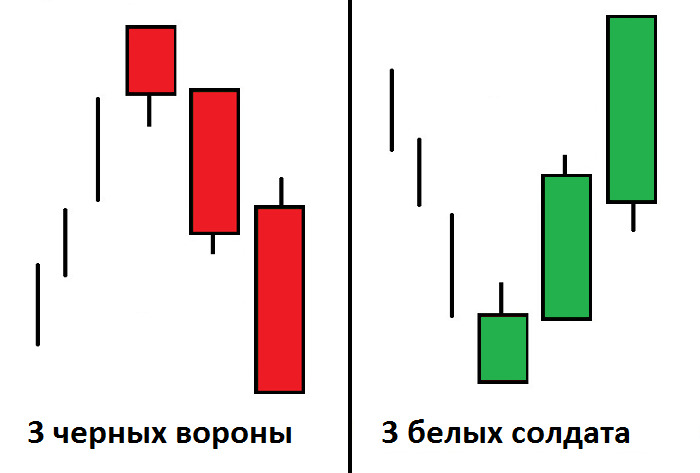

In [12]:
def detection_3_grow_candle(data, filtr='NO'):
    """
    Функция для детекции бычьего паттерна 3 растущих свеч на ценовых данныx.
    

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_loss_candle_after_pattern' - паттерн подтверждается 1 падающей свечой после него
        - '1_loss_candle_before_pattern' - паттерн подтверждается 1 падающей свечой до него  

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = '3_grow_candle'
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие 
    base_condition = (
        (body > 0) & 
        (body.shift(-1) > 0) &
        (body.shift(-2) > 0))

    if filtr == 'NO':
        # Отмечаем 3 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_after_pattern':
        # 4 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-3) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_loss_candle_before_pattern':
        # 4 свечи: паттерн + 1 подтверждения
        pattern_mask = base_condition & (body.shift(1) < 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    data['filtr'] = filtr
        
    
    return data
    
       

In [13]:
def detection_3_loss_candle(data, filtr='NO'):
    """
    Функция для детекции медвежьего паттерна 3 падающих свеч на ценовых данныx.
    

    Параметры:
    ----------
    data : pd.DataFrame
        DataFrame с ценовыми данными, должен содержать колонки:
        - 'open': цены открытия
        - 'close': цены закрытия  
        - 'high', 'low', 'volume' для расширенных фильтров
        
    filtr : str, optional, default='NO'
        Тип фильтра для подтверждения паттерна:
        
        Базовые фильтры:
        - 'NO' - детекция паттерна без дополнительных фильтров
        
        Фильтры подтверждения бычьим движением:
        - '1_grow_candle_after_pattern' - паттерн подтверждается 1 растущей свечой после него
        - '1_grow_candle_before_pattern' - паттерн подтверждается 1 растущей свечой до него  

    Возвращает:
    -----------
    pd.DataFrame
        Исходный DataFrame с добавленной колонкой:
        - 'pattern': бинарный indicator (0/1), где 1 обозначает наличие паттерна
        - 'signal': бинарный indicator (0/1), где 1 обозначает сигнал на вход(следующая свеча после паттерна), создано для облегчения проверки стратегий
        
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['strategy'] = '3_grow_candle'
    
    # Векторизованные вычисления
    body = data['close'] - data['open']
    
    # Базовое условие 
    base_condition = (
        (body < 0) & 
        (body.shift(-1) < 0) &
        (body.shift(-2) < 0))

    if filtr == 'NO':
        # Отмечаем 3 свечи паттерна
        pattern_mask = base_condition
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        # Сигнал - следующая свеча после завершения паттерна
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_after_pattern':
        # 4 свечи: паттерн + 1 подтверждение
        pattern_mask = base_condition & (body.shift(-3) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(3).fillna(False), 'pattern'] = 1
        # Сигнал - после подтверждающей свечи
        data.loc[pattern_mask.shift(4).fillna(False), 'signal'] = 1
        
    elif filtr == '1_grow_candle_before_pattern':
        # 4 свечи: паттерн + 1 подтверждения
        pattern_mask = base_condition & (body.shift(1) > 0)
        data.loc[pattern_mask, 'pattern'] = 1
        data.loc[pattern_mask.shift(1).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(2).fillna(False), 'pattern'] = 1
        data.loc[pattern_mask.shift(-1).fillna(False), 'pattern'] = 1
        # Сигнал - после второй подтверждающей свечи
        data.loc[pattern_mask.shift(3).fillna(False), 'signal'] = 1
    
    data['filtr'] = filtr
    
    return data
    
       

# Проверка эффективности паттернов

In [15]:
def calculate_trade_statistics(data, commision=0.01, full='NO', direction='bull'):
    if direction == 'bull':
        def lst_trade_statistics_bull(data, commision=commision):
            # Указываем максимальный размер датасета
            max_index = len(data) - 50
            # список для результатов
            all_results = []
            signal_indices = data.index[data['signal'] == 1]
            signal_indices = signal_indices[signal_indices < max_index]
            for i in range(1, 51):
                entry_indices = signal_indices
                exit_indicies = signal_indices + i 
                # Проверяем корректность индексов
                valid_mask = exit_indicies < len(data)
                valid_entry_indices = entry_indices[valid_mask]
                valid_exit_indicies = exit_indicies[valid_mask]
                
                entry_price = data['open'].iloc[valid_entry_indices].values
                exit_price = data['close'].iloc[valid_exit_indicies].values
                profit = exit_price - entry_price
                commision = commision
                profit_net = np.where(profit > 0, profit * (1 - commision), profit * (1 + commision))
                all_results.append(profit_net)
            return all_results
    
        lst = lst_trade_statistics_bull(data)
    
    elif direction == 'bear':
        def lst_trade_statistics_bear(data, commision=commision):
            # Указываем максимальный размер датасета
            max_index = len(data) - 50
            # список для результатов
            all_results = []
            signal_indices = data.index[data['signal'] == 1]
            signal_indices = signal_indices[signal_indices < max_index]
            for i in range(1, 51):
                entry_indices = signal_indices
                exit_indicies = signal_indices + i 
                # Проверяем корректность индексов
                valid_mask = exit_indicies < len(data)
                valid_entry_indices = entry_indices[valid_mask]
                valid_exit_indicies = exit_indicies[valid_mask]
                
                entry_price = data['open'].iloc[valid_entry_indices].values
                exit_price = data['close'].iloc[valid_exit_indicies].values
                profit = entry_price - exit_price
                commision = commision
                profit_net = np.where(profit > 0, profit * (1 - commision), profit * (1 + commision))
                all_results.append(profit_net)
            return all_results
    
        lst = lst_trade_statistics_bear(data)
    
    def calculate_relative_drawdown(lst):
        cumulative = np.cumsum(lst)
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (running_max - cumulative) 
        return np.max(drawdown)
        
    # Предварительно создаем шаблоны словарей
    template_full = {
        'n': 0.0, 'profit': 0.0, 'profit_net': 0.0, 'loss_net': 0.0,
        'count_of_trade': 0.0, 'percent_of_profit_trade': 0.0, 
        'percent_of_loss_trade': 0.0, 'std_profit': 0.0,
        'avg_profit_trade': 0.0, 'avg_loss_trade': 0.0,
        'profit_factor': 0.0, 'max_drawdown': 0.0, 'cumsum': 0.0
    }
    
    template_short = {
        'n': 0.0, 'profit': 0.0, 'count_of_trade': 0.0,
        'percent_of_profit_trade': 0.0, 'percent_of_loss_trade': 0.0,
        'profit_factor': 0.0, 'max_drawdown': 0.0
    }
    
    results = []
    
    for n, returns in enumerate(lst, 1):
        returns = np.array(returns)
        
        if len(returns) == 0:
            # Пустые результаты
            if full == 'YES':
                result = template_full.copy()
                result['n'] = n
                results.append(result)
            else:
                result = template_short.copy()
                result['n'] = n
                results.append(result)
            continue
        
        # Векторизованные вычисления
        is_positive = returns > 0
        positive_returns = returns[is_positive]
        negative_returns = returns[~is_positive]
        
        profit_total = np.sum(returns)
        profit_net = np.sum(positive_returns)
        loss_net = np.sum(negative_returns)
        count_trades = len(returns)
        percent_profit = np.mean(is_positive) * 100
        percent_loss = 100 - percent_profit
        profit_factor = profit_net / abs(loss_net) if loss_net < 0 else float('inf')
        max_drawdown = calculate_relative_drawdown(returns)
        cumsum_result = np.cumsum(returns)
        
        if full == 'YES':
            result = template_full.copy()
            result.update({
                'n': n,
                'profit': np.round(profit_total, 2),
                'profit_net': np.round(profit_net, 2),
                'loss_net': np.round(loss_net, 2),
                'count_of_trade': count_trades,
                'percent_of_profit_trade': np.round(percent_profit, 1),
                'percent_of_loss_trade': np.round(percent_loss, 1),
                'std_profit': np.round(np.std(returns), 2),
                'avg_profit_trade': np.round(np.mean(positive_returns) if len(positive_returns) > 0 else 0, 2),
                'avg_loss_trade': np.round(np.mean(negative_returns) if len(negative_returns) > 0 else 0, 2),
                'profit_factor': np.round(profit_factor, 2),
                'max_drawdown': np.round(max_drawdown, 2),
                'cumsum': cumsum_result.tolist()
            })
        else:
            result = template_short.copy()
            result.update({
                'n': n,
                'profit': np.round(profit_total, 2),
                'count_of_trade': count_trades,
                'percent_of_profit_trade': np.round(percent_profit, 1),
                'percent_of_loss_trade': np.round(percent_loss, 1),
                'profit_factor': np.round(profit_factor, 2),
                'max_drawdown': np.round(max_drawdown, 2)
            })
        
        results.append(result)
    

    # Создаем DataFrame и сортируем
    df = pd.DataFrame(results)
    df_ticker_per = data[['per', 'ticker', 'filtr', 'strategy']][:len(df)]
    df_last = pd.concat([df_ticker_per, df], axis=1)
    df_last.sort_values('profit_factor', ascending=False, inplace=True)
    
    return df_last

In [16]:
# Список l это список со всеми таймфреймами, без детекции паттернов

In [22]:
# Проверка всех написанных стратегий
dict_strategy_and_filtr = {detection_bullish_engulfing_pattern : ['bull', ['NO', '1_grow_candle_after_pattern', '2_grow_candle_after_pattern', '1_loss_candle_before_pattern', '2_loss_candle_before_pattern']],
                           detection_bearish_engulfing_pattern : ['bear', ['NO', '1_loss_candle_after_pattern', '2_loss_candle_after_pattern', '1_grow_candle_before_pattern', '2_grow_candle_before_pattern']],
                           detection_bullish_harami_pattern : ['bull', ['NO', '1_grow_candle_after_pattern', '2_grow_candle_after_pattern', '1_loss_candle_before_pattern', '2_loss_candle_before_pattern']],
                           detection_bearish_harami_pattern : ['bear', ['NO', '1_loss_candle_after_pattern', '2_loss_candle_after_pattern', '1_grow_candle_before_pattern', '2_grow_candle_before_pattern']],
                           detection_3_grow_candle : ['bull', ['NO', '1_loss_candle_after_pattern', '1_loss_candle_before_pattern']],
                           detection_3_loss_candle : ['bear', ['NO', '1_grow_candle_after_pattern', '1_grow_candle_before_pattern']]}

list_df_with_all_strategy_filtr = []                          
for df in l:
    for strategy, filtr in dict_strategy_and_filtr.items():
        for i in filtr[1]:
            df_str_filtr = strategy(df, filtr=i)
            res = calculate_trade_statistics(df_str_filtr, commision=0.01, full='YES', direction=filtr[0])
            list_df_with_all_strategy_filtr.append(res)
            
combined_df = pd.concat(list_df_with_all_strategy_filtr, ignore_index=True)
combined_df.sort_values('profit_factor', ascending=False)

,per,ticker,filtr,strategy,n,profit,profit_net,loss_net,count_of_trade,percent_of_profit_trade,percent_of_loss_trade,std_profit,avg_profit_trade,avg_loss_trade,profit_factor,max_drawdown,cumsum
6700,4h,SBRF,2_loss_candle_before_pattern,bullish_engulfing_pattern,50,44365.09,83450.07,-39084.98,132,57.6,42.4,1250.82,1098.03,-697.95,2.14,6633.68,"[891.99, 2009.7, 2685.87, 3508.56, 2641.98, 13..."
8750,D,SBRF,2_grow_candle_before_pattern,bearish_harami_pattern,1,6394.13,12507.66,-6113.53,62,56.5,43.5,450.85,357.36,-226.43,2.05,1935.16,"[-5.05, -65.65, 161.06, -9.629999999999995, 17..."
8700,D,SBRF,1_grow_candle_before_pattern,bearish_harami_pattern,1,10073.62,20203.92,-10130.30,103,59.2,40.8,423.44,331.21,-241.20,1.99,1565.57,"[-5.05, -65.65, 161.06, -9.629999999999995, 17..."
6701,4h,SBRF,2_loss_candle_before_pattern,bullish_engulfing_pattern,49,39718.54,80527.59,-40809.05,132,57.6,42.4,1253.44,1059.57,-728.73,1.97,7204.86,"[693.0, 1762.2, 2454.21, 3276.9, 2403.25, 934...."
7950,D,SBRF,1_loss_candle_before_pattern,bullish_engulfing_pattern,12,23342.56,50922.63,-27580.07,78,64.1,35.9,1475.94,1018.45,-985.00,1.85,5575.79,"[171.27, 88.45, 628.0, 748.78, 855.69999999999..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8047,D,SBRF,2_loss_candle_before_pattern,bullish_engulfing_pattern,2,-8266.26,4720.32,-12986.58,29,27.6,72.4,672.51,590.04,-618.41,0.36,8916.74,"[-776.69, -764.8100000000001, -370.79000000000..."
8649,D,SBRF,1_loss_candle_after_pattern,bearish_harami_pattern,3,-21928.40,11863.17,-33791.57,107,37.4,62.6,562.65,296.58,-504.35,0.35,21683.98,"[-244.42000000000002, -668.62, -518.14, -1052...."
8048,D,SBRF,2_loss_candle_before_pattern,bullish_engulfing_pattern,3,-11439.28,5100.48,-16539.76,29,20.7,79.3,875.36,850.08,-719.12,0.31,11429.87,"[-686.8, -725.18, -9.409999999999968, -95.2599..."
8049,D,SBRF,2_loss_candle_before_pattern,bullish_engulfing_pattern,1,-6121.04,2721.51,-8842.55,29,31.0,69.0,463.65,302.39,-442.13,0.31,5765.43,"[-474.7, -710.03, -355.60999999999996, -435.4,..."


In [55]:
combined_df['profit_factor_rank'] = combined_df['profit_factor'].rank() # Больше лучше
combined_df['max_drawdown_rank'] = combined_df['max_drawdown'].rank(ascending=False) # Меньше лучше
combined_df['best_model'] = combined_df['profit_factor_rank'] + combined_df['max_drawdown_rank']
combined_df.sort_values('best_model', ascending=False)

,per,ticker,filtr,strategy,n,profit,profit_net,loss_net,count_of_trade,percent_of_profit_trade,percent_of_loss_trade,std_profit,avg_profit_trade,avg_loss_trade,profit_factor,max_drawdown,cumsum,profit_factor_rank,max_drawdown_rank,best_model
8700,D,SBRF,1_grow_candle_before_pattern,bearish_harami_pattern,1,10073.62,20203.92,-10130.30,103,59.2,40.8,423.44,331.21,-241.20,1.99,1565.57,"[-5.05, -65.65, 161.06, -9.629999999999995, 17...",9098.0,9097.0,18195.0
8750,D,SBRF,2_grow_candle_before_pattern,bearish_harami_pattern,1,6394.13,12507.66,-6113.53,62,56.5,43.5,450.85,357.36,-226.43,2.05,1935.16,"[-5.05, -65.65, 161.06, -9.629999999999995, 17...",9099.0,9087.0,18186.0
6850,4h,SBRF,2_loss_candle_after_pattern,bearish_engulfing_pattern,1,5790.38,15645.96,-9855.58,151,57.6,42.4,246.29,179.84,-153.99,1.59,1431.98,"[2.9699999999999998, -43.49, -12.8, -131.98000...",9020.5,9098.0,18118.5
6713,4h,SBRF,2_loss_candle_before_pattern,bullish_engulfing_pattern,9,11721.21,28789.20,-17067.99,132,51.5,48.5,490.39,423.37,-266.69,1.69,3065.15,"[149.49, 242.55, 106.20000000000002, 275.49, 1...",9069.0,9034.0,18103.0
8256,D,SBRF,2_grow_candle_before_pattern,bearish_engulfing_pattern,1,2349.34,6895.35,-4546.01,36,44.4,55.6,514.44,430.96,-227.30,1.52,1230.85,"[-55.55, -461.57, -211.1, 252.22, 207.78, 177....",8995.5,9100.0,18095.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7749,4h,SBRF,1_grow_candle_after_pattern,3_grow_candle,50,-155612.81,355118.94,-510731.75,936,44.1,55.9,1430.75,859.85,-976.54,0.70,165548.18,"[590.04, 1080.09, 1583.01, 1946.34, 2013.65999...",113.0,78.0,191.0
8995,D,SBRF,NO,3_grow_candle,40,-125108.88,304678.44,-429787.32,424,38.4,61.6,2532.76,1869.19,-1646.69,0.71,182142.97,"[292.05, -339.2, -1137.1, -2227.8999999999996,...",138.5,44.0,182.5
8994,D,SBRF,NO,3_grow_candle,41,-126812.77,308479.05,-435291.82,424,37.0,63.0,2588.42,1964.83,-1630.31,0.71,184638.24,"[-23.23, -1003.94, -1853.35, -3050.2, -4327.85...",138.5,39.0,177.5
8997,D,SBRF,NO,3_grow_candle,49,-131919.23,329571.99,-461491.22,424,34.2,65.8,2846.89,2272.91,-1654.09,0.71,201330.87,"[-165.64000000000001, -847.39, -2224.02, -3761...",138.5,16.0,154.5


In [57]:
combined_data = combined_df[combined_df['count_of_trade'] >= 500]
combined_data.sort_values('best_model', ascending=False)

,per,ticker,filtr,strategy,n,profit,profit_net,loss_net,count_of_trade,percent_of_profit_trade,percent_of_loss_trade,std_profit,avg_profit_trade,avg_loss_trade,profit_factor,max_drawdown,cumsum,profit_factor_rank,max_drawdown_rank,best_model
1400,15 min,SBRF,2_grow_candle_after_pattern,bullish_engulfing_pattern,5,19401.44,68125.86,-48724.42,1637,51.4,48.6,131.29,80.91,-61.29,1.40,1992.18,"[-16.16, -11.21, 10.57, 19.48, -9.809999999999...",8900.0,9084.0,17984.0
1401,15 min,SBRF,2_grow_candle_after_pattern,bullish_engulfing_pattern,6,19992.31,73224.36,-53232.05,1637,52.2,47.8,138.82,85.74,-67.98,1.38,1629.85,"[-30.3, -37.370000000000005, -15.5900000000000...",8873.0,9095.0,17968.0
1402,15 min,SBRF,2_grow_candle_after_pattern,bullish_engulfing_pattern,4,16778.44,62677.89,-45899.45,1637,50.5,49.5,125.68,75.79,-56.67,1.37,2286.20,"[-18.18, -15.21, 6.57, 8.55, -23.77, -54.07, -...",8855.0,9072.0,17927.0
1403,15 min,SBRF,2_grow_candle_after_pattern,bullish_engulfing_pattern,3,12547.33,53189.73,-40642.40,1637,49.7,50.3,105.07,65.34,-49.38,1.31,1407.79,"[-3.0300000000000002, 4.89, 36.57, 40.53, 0.13...",8745.0,9099.0,17844.0
1404,15 min,SBRF,2_grow_candle_after_pattern,bullish_engulfing_pattern,8,18607.08,83049.12,-64442.04,1637,51.9,48.1,158.39,97.70,-81.88,1.29,2803.41,"[-37.37, -51.51, -38.64, -28.740000000000002, ...",8698.5,9052.0,17750.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7746,4h,SBRF,1_grow_candle_after_pattern,3_grow_candle,45,-124995.54,342963.72,-467959.26,936,44.3,55.7,1368.71,826.42,-898.19,0.73,134596.64,"[526.68, 943.47, 1414.71, 1758.24, 1921.59, 18...",193.0,205.0,398.0
7747,4h,SBRF,1_grow_candle_after_pattern,3_grow_candle,48,-129854.61,359060.13,-488914.74,936,44.4,55.6,1419.88,863.13,-940.22,0.73,142097.28,"[585.09, 1025.64, 1508.7600000000002, 1859.220...",193.0,164.0,357.0
7799,4h,SBRF,1_grow_candle_before_pattern,3_grow_candle,50,-135660.97,368902.71,-504563.68,933,44.4,55.6,1466.55,891.07,-972.18,0.73,147621.16,"[602.91, 1125.63, 1600.8300000000002, 1953.270...",193.0,136.0,329.0
7748,4h,SBRF,1_grow_candle_after_pattern,3_grow_candle,49,-147638.58,351505.44,-499144.02,936,44.2,55.8,1412.14,849.05,-956.21,0.70,159174.87,"[554.4, 1027.62, 1530.54, 1873.08, 1955.25, 17...",113.0,95.0,208.0


<Axes: >

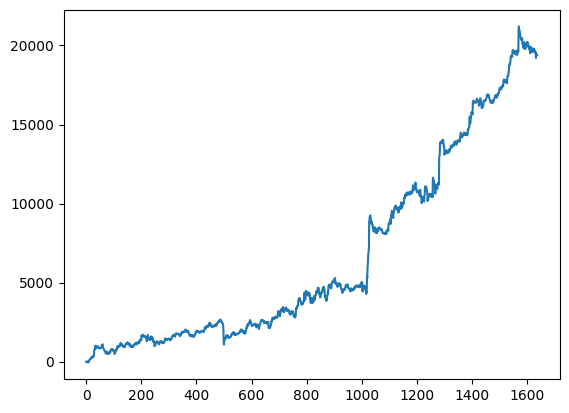

In [59]:
import seaborn as sns
sns.lineplot(combined_data.loc[1400, 'cumsum'])

In [19]:
# Давайте подумаем. около 16 лет торгов, в неделю хотелось бы хотя бы 1 сделку, то есть в месяц 4, а в год 48, тогда за 16 лет порядка 768, давайте нижняя граница будет 500

In [20]:
# from ipywidgets import interact, Dropdown

# def interactive_filter_jupyter(ticker='Все', filtr='Все', per='Все', strategy='Все'):
#     filtered_df = combined_df.copy()
    
#     if ticker != 'Все':
#         filtered_df = filtered_df[filtered_df['ticker'] == ticker]
#     if filtr != 'Все':
#         filtered_df = filtered_df[filtered_df['filtr'] == filtr]
#     if per != 'Все':
#         filtered_df = filtered_df[filtered_df['per'] == per]
#     if strategy != 'Все':
#         filtered_df = filtered_df[filtered_df['strategy'] == strategy]
    
#     display(filtered_df)

# interact(
#     interactive_filter_jupyter,
#     ticker=['Все'] + list(combined_df['ticker'].unique()),
#     filtr=['Все'] + list(combined_df['filtr'].unique()),
#     per=['Все'] + list(combined_df['per'].unique()),
#     strategy=['Все'] + list(combined_df['strategy'].unique())
# )

# 1. В следующий раз надо уже окончательно разобраться с функциями детекции паттерна, благо основа у нас уже есть. + Напишем 3 новых паттерна и проверим их. 
# 2. Проверить функцию для счёта прибыли на корректность
# 3. Сделать какую-то сводку результатов и отобрать лучшие модельки с которыми можно работать дальше.
# 4. Функция для подбора тейка и стопа 

Как говорится, в следующей серии:
- Везде пишем информацию про функции, чтобы было удобно потом работать
- Надо собрать воедино всё, что мы сегодня сделали:
  * Дописать все функции детекции паттернов, сначала для паттернов из 2 свеч, потом для 3 свеч.
  * Написать функцию, которая удобно будет выводит статистические результаты нашиз стратегий после удержания позиции N дней. Надо обязательно разделить на бычьи формации и медвежьи и плясать уже от этого. Может быть стоит убрать такое количество параметров в табличке, так как половина из них неэффективна, оставить основные 5 и всё.
  * Дописать функцию, которая разворачивает датафрейм, написано для 2 свечей, надо до 3 свечей.
  * Дописать функции, создающие новые признаки (поработать со свечками, даты, волатильность и прочее)

- Попробывать придумать механизм для уже обычной торговой системы на основе паттернов, (стоп, тейк) + оптимизация параметров
- Написать итерактивный дашборд, где я смогу визуализировать результаты стратегии
- После изучения машинного обучения, пробуем сделать классификацию или кластеризацию наших паттернов
- Надо объединить процесс создания статистики по какой-либо стратегии, то есть сделать 1 функцию, которая будет получать сырой датафрейм, таймфрейм и формацию, результаты которой мы хотим постмотреть. Так будет хорошо.


Сегодня я вообщем наконец-то нашел подход к написанию паттернов, поэтому следующие напишем достаточно быстро, думаю, что за 1 подход.

Далее надо бы проверить функцию, которая считает результаты наших стратегий.

Когда будут написаны все 7 паттернов и они будут проверены, мы пишем что-то, что позволит собрать все результаты в единный датафрейм для анализа. 

Далее попробуем написать что-то типо оптимизационной функции, которая подбирает автоматически наилучший стоп и тейк.